# _**ДАТАСЕТ ПРОДАЖ ТОВАРОВ В ТУРЕЦКОМ ИНТЕРНЕТ-МАГАЗИНЕ**_

## <span style="color: darkred;">Цель:</span> провести EDA, посмотреть структуру и динамику продаж, выявить зависимости, сформулировать выводы и рекомендации.

<br>

--- 

**Сначала подготовим данные для работы, проведем первичный анализ и выявим аномальные значения(выбросы)/ null`ы/ дубликаты:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats

df = pd.read_csv('ecommerce_customer_behavior_dataset.csv')
display(Markdown('<br>_Посмотрим на срез датасета (первые 5 строк), чтобы иметь общее представление о данных:_'))
print(df.head(5))

# (2) Приводим Date к формату даты:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') 

display(Markdown('_<br>Посмотрим на типы данных по столбцам и количество null-значений:_'))
df.info() # (1) Видим, что Date в формате Object

display(Markdown('<br>_Выведем основную статистику по столбцам:_<br>'))
df.describe().round(1)

<br>_Посмотрим на срез датасета (первые 5 строк), чтобы иметь общее представление о данных:_

     Order_ID Customer_ID        Date  Age  Gender      City Product_Category  \
0  ORD_001337  CUST_01337  2023-01-01   27  Female     Bursa             Toys   
1  ORD_004885  CUST_04885  2023-01-01   42    Male     Konya             Toys   
2  ORD_004507  CUST_04507  2023-01-01   43  Female    Ankara             Food   
3  ORD_000645  CUST_00645  2023-01-01   32    Male  Istanbul      Electronics   
4  ORD_000690  CUST_00690  2023-01-01   40  Female  Istanbul           Sports   

   Unit_Price  Quantity  Discount_Amount  Total_Amount    Payment_Method  \
0       54.28         1             0.00         54.28        Debit Card   
1      244.90         1             0.00        244.90       Credit Card   
2       48.15         5             0.00        240.75       Credit Card   
3      804.06         1           229.28        574.78       Credit Card   
4      755.61         5             0.00       3778.05  Cash on Delivery   

  Device_Type  Session_Duration_Minutes  Pages_Viewed  I

_<br>Посмотрим на типы данных по столбцам и количество null-значений:_

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Order_ID                  5000 non-null   object        
 1   Customer_ID               5000 non-null   object        
 2   Date                      5000 non-null   datetime64[ns]
 3   Age                       5000 non-null   int64         
 4   Gender                    5000 non-null   object        
 5   City                      5000 non-null   object        
 6   Product_Category          5000 non-null   object        
 7   Unit_Price                5000 non-null   float64       
 8   Quantity                  5000 non-null   int64         
 9   Discount_Amount           5000 non-null   float64       
 10  Total_Amount              5000 non-null   float64       
 11  Payment_Method            5000 non-null   object        
 12  Device_Type         

<br>_Выведем основную статистику по столбцам:_<br>

,Date,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,2023-08-16 09:16:24.959999744,35.0,455.8,2.2,24.9,983.1,14.6,9.0,6.5,3.9
min,2023-01-01 00:00:00,18.0,5.2,1.0,0.0,7.9,1.0,1.0,1.0,1.0
25%,2023-04-30 00:00:00,27.0,76.6,1.0,0.0,122.5,8.0,7.0,4.0,3.0
50%,2023-08-17 00:00:00,35.0,183.0,2.0,0.0,337.9,13.0,9.0,6.0,4.0
75%,2023-12-06 00:00:00,42.0,513.9,3.0,8.8,979.7,19.0,11.0,8.0,5.0
max,2024-03-26 00:00:00,75.0,7159.4,5.0,1525.6,22023.9,73.0,24.0,25.0,5.0
std,NaN,11.1,712.5,1.4,88.4,1899.0,8.7,2.8,3.5,1.1


Посчитаем количество дубликатов:

In [2]:
print(f'Дубликаты: {df.duplicated().sum()}')

Дубликаты: 0


<br>

Видим, что медиана по столбцу **Total_Amount** (_общая сумма покупок пользователя_) сильно меньше среднего значения, а максимальное значение _является выбросом_ - всё это говорит _о тяжелом правом хвосте_ в распределении значений.

Логарифмируем значения в колонке для проверки на **нормальное распределение**:

<br>

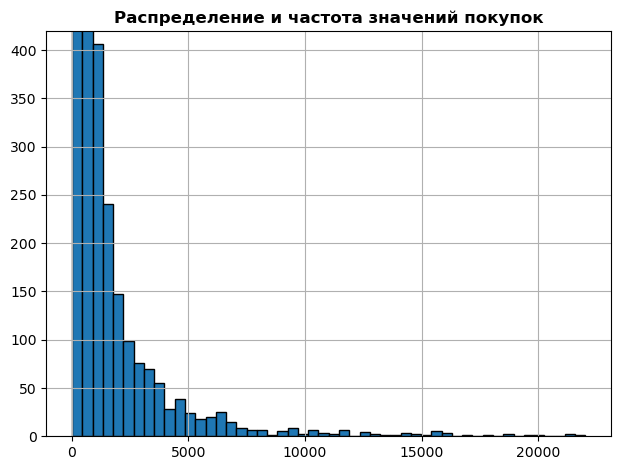

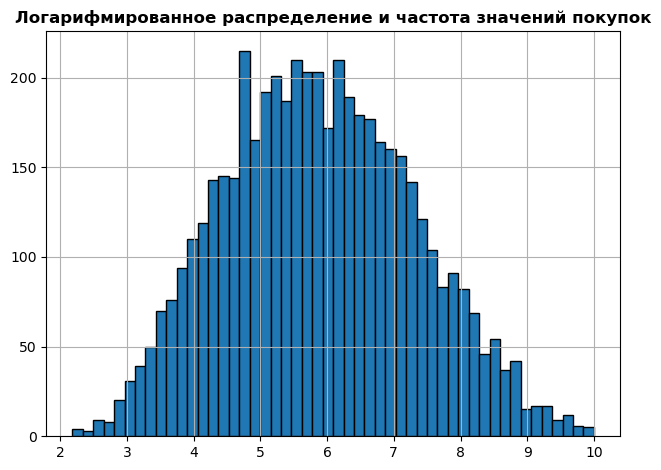

In [3]:
df['Total_Amount'].hist(bins=50, edgecolor='black', linewidth=1)
plt.title('Распределение и частота значений покупок', fontweight='bold')
plt.tight_layout()
plt.ylim(0, 420)
plt.show()

logarifmed = np.log1p(df['Total_Amount']) #логарифмируем столбец
 
logarifmed.hist(bins=50, edgecolor='black', linewidth=1)
plt.title('Логарифмированное распределение и частота значений покупок', fontweight='bold')
plt.tight_layout()
plt.show()

Видим в целом нормальное распределение значений.


В датасете много категорий, данные достаточно информативны. Поэтому можно посмотреть и посчитать самые *разнообразные* показатели и метрики: **половозрастную структуру покупателей, категориальную структуру ассортимента, зависимость предлпочтений в покупках от пола и возраста, общее удержание (процент в принципе вернувшихся покупателей), предпочитаемое устройство для покупки и его корреляцию с возрастом/полом и т.д.**



---
Для начала посчитаем базовые метрики:


In [4]:
print(f'Общая выручка: {df['Total_Amount'].sum()}')
print(f'Количество заказов: {df['Order_ID'].nunique()}')
print(f'Средний чек: {(df['Total_Amount'].sum() / df['Order_ID'].nunique()).round(1)}')
print(f'Количество уникальных клиентов: {df['Customer_ID'].nunique()}')
print(f'Среднее количество товаров на заказ: {df['Quantity'].mean()}')

Общая выручка: 4915544.57
Количество заказов: 5000
Средний чек: 983.1
Количество уникальных клиентов: 5000
Среднее количество товаров на заказ: 2.22


Интересно, что все покупатели в нашей выборки уникальные. То есть за время наблюдений (01.2023-03.2024) каждый клиент совершил лишь одну покупку. При этом покупки могли быть соверешены раньше наблюдаемого периода (судя по столбцу _Is_Returning_Customer_).

---
Посмотрим динамику продаж по времени:

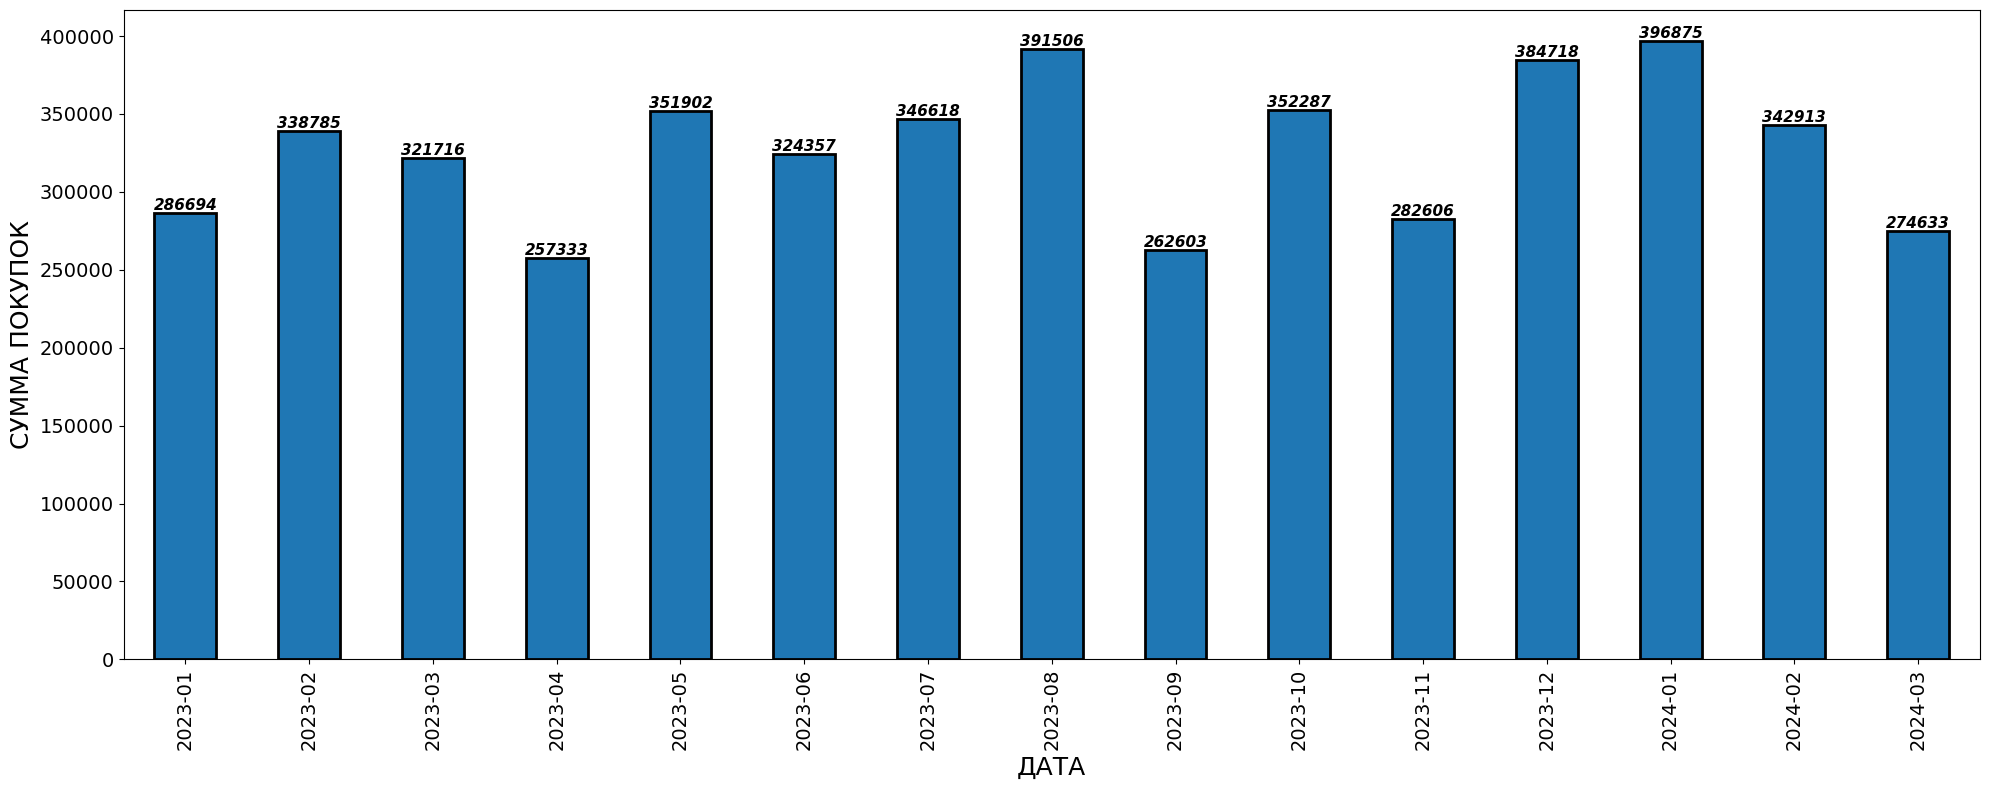

In [5]:
date_sales = df.groupby(df['Date'].dt.strftime('%Y-%m'))['Total_Amount'].sum()

labels = date_sales.plot(figsize=(20,8), kind='bar', fontsize=14, edgecolor='black', linewidth=2)
labels.bar_label(labels.containers[0], fmt='%.0f', fontsize=11, fontweight='bold', fontstyle='italic')
plt.xlabel('ДАТА', fontsize=18)
plt.ylabel('СУММА ПОКУПОК', fontsize=18)
plt.tight_layout()
plt.show()

В целом, из-за небольшого размера временного отрезка (15 месяцев), невозможно выявить какой-либо тренд или сезонность.

---

Анализ продаж по кварталам также не выявил какой либо закономерность - объем продаж +- одинаковый за весь рассматриваемый период в квартальном разрезе.

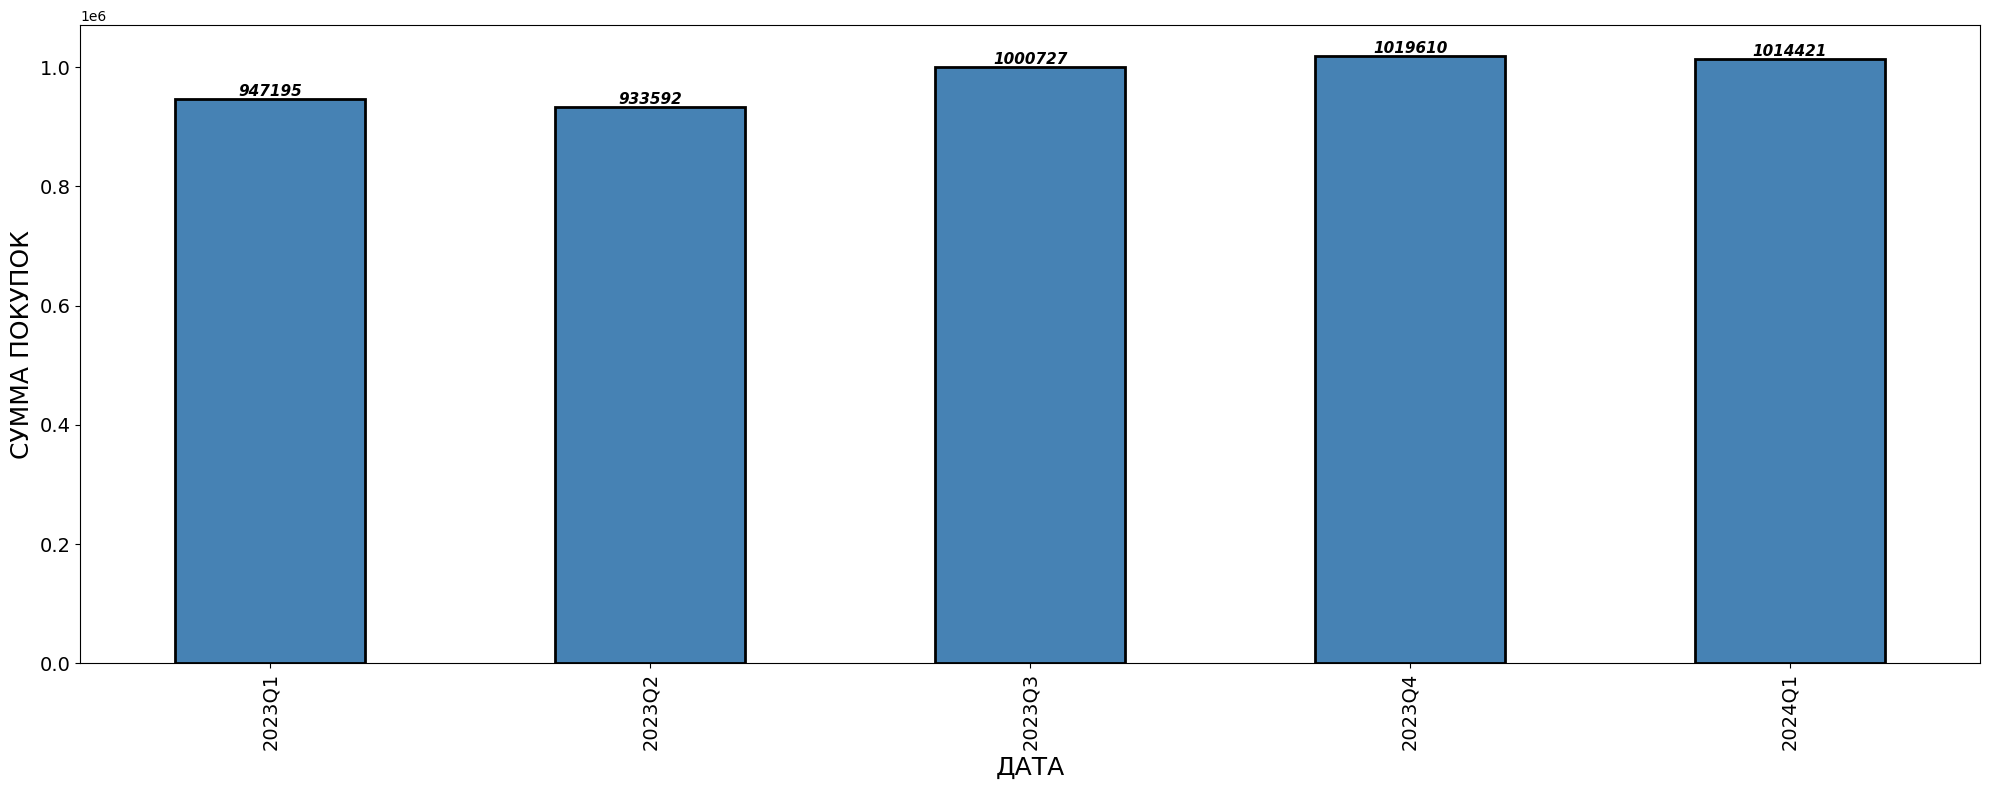

In [6]:
date_sales_q = df.groupby(df['Date'].dt.to_period('Q'))['Total_Amount'].sum()

labels = date_sales_q.plot(figsize=(20,8), kind='bar', fontsize=14, edgecolor='black', linewidth=2, color='steelblue')
labels.bar_label(labels.containers[0], fmt='%.0f', fontsize=11, fontweight='bold', fontstyle='italic')
plt.xlabel('ДАТА', fontsize=18)
plt.ylabel('СУММА ПОКУПОК', fontsize=18)
plt.tight_layout()
plt.show()

---

Далее сравним объемы продаж в разрезе пола.

Видим, что **женщины** совершили чуть больше покупок, чем **мужчины**. Также в выборке есть покупатели, не указавшие пол (_всего 1,2% от всех покупок_).

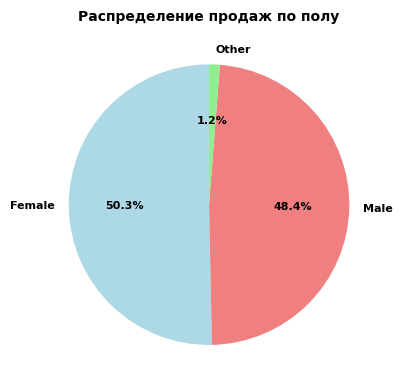

In [7]:
gender_sales = df.groupby(['Gender'])['Total_Amount'].sum()

plt.figure(figsize=(5, 4))
plt.pie(gender_sales, 
        labels=gender_sales.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['lightblue', 'lightcoral', 'lightgreen'],
        textprops={'fontsize': 8, 'fontweight': 'bold'}
       )
plt.title('Распределение продаж по полу', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

---

Далее рассмотрим возрастную структуру продаж:

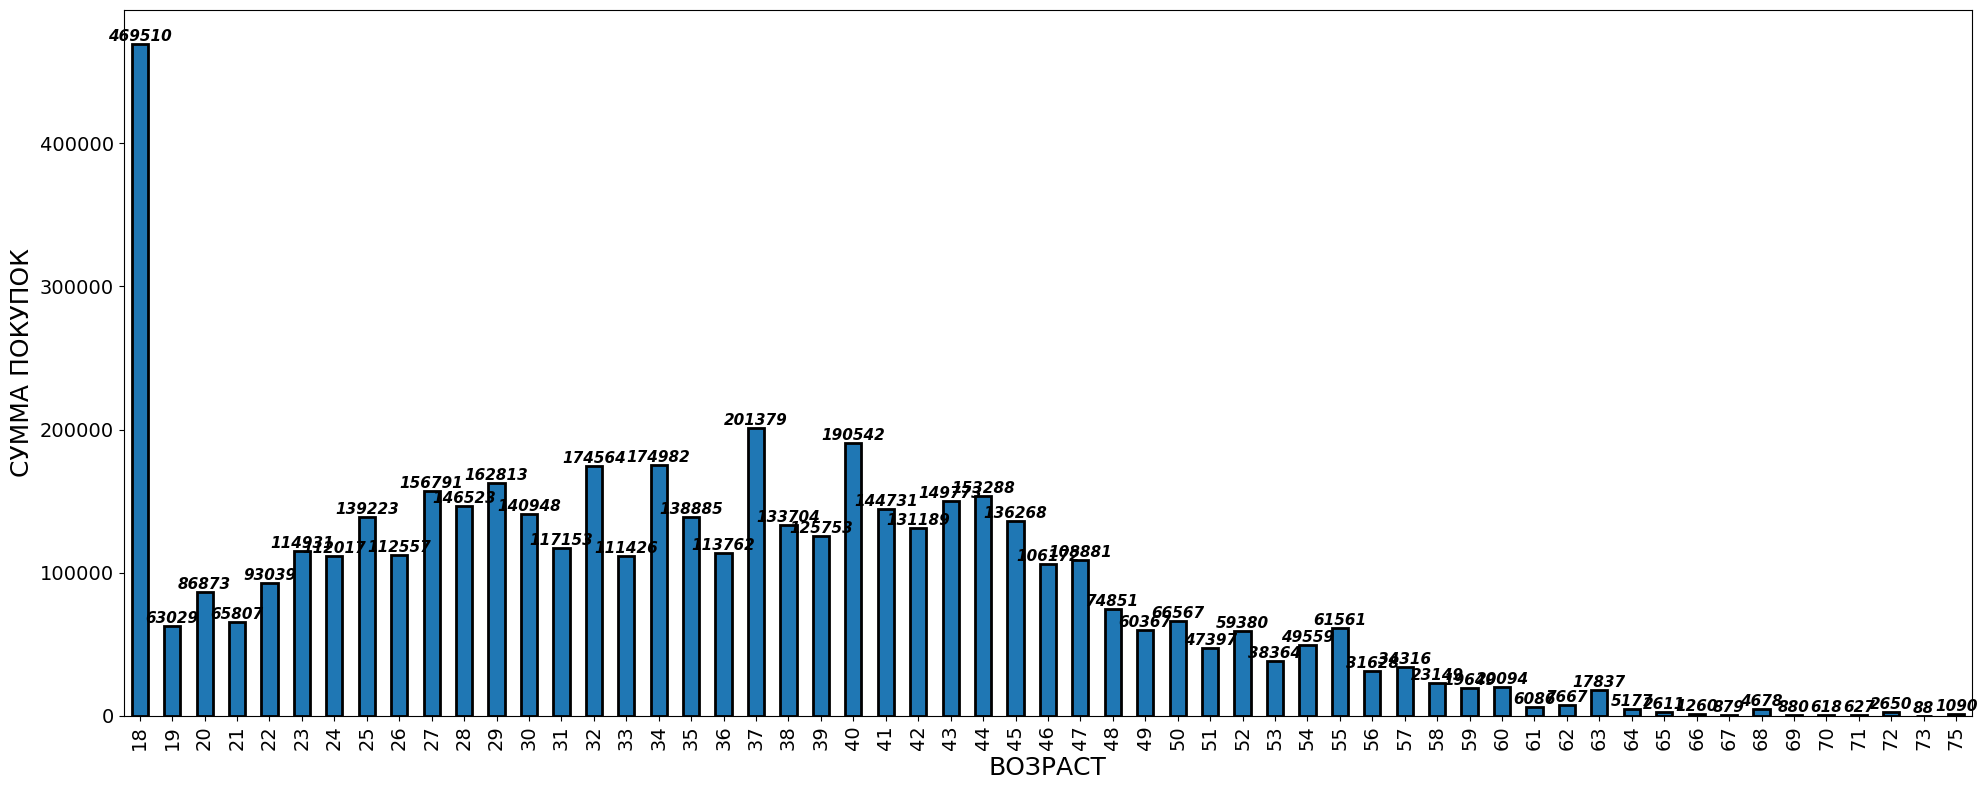

In [8]:
age_sales = df.groupby(df['Age'])['Total_Amount'].sum()

labels = age_sales.plot(figsize=(20,8), kind='bar', fontsize=14, edgecolor='black', linewidth=2)
labels.bar_label(labels.containers[0], fmt='%.0f', fontsize=11, fontweight='bold', fontstyle='italic')
plt.xlabel('ВОЗРАСТ', fontsize=18)
plt.ylabel('СУММА ПОКУПОК', fontsize=18)
plt.tight_layout()
plt.show()

Видим, что покупатели в возрасте __18 лет__ - **ТОП-1** по совокупному объему продаж. Что примечательно - далее идет резкий спад.

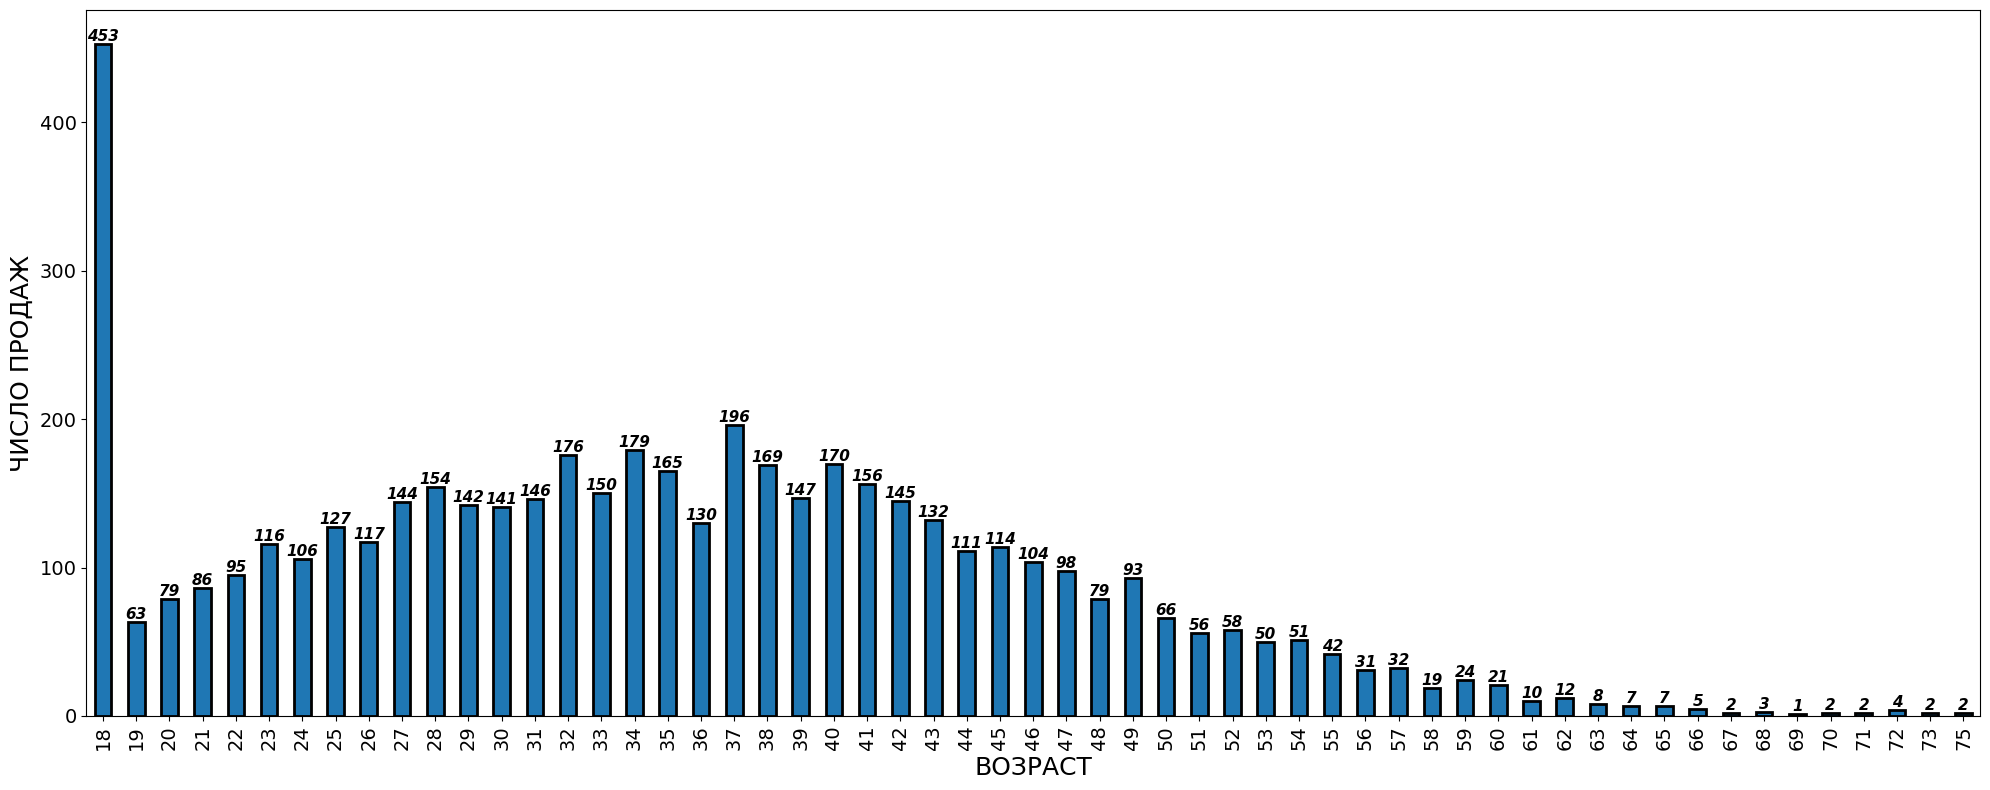

In [9]:
#Также построим график числа продаж по возрастам

age_sales = df.groupby(df['Age'])['Total_Amount'].count()

labels = age_sales.plot(figsize=(20,8), kind='bar', fontsize=14, edgecolor='black', linewidth=2)
labels.bar_label(labels.containers[0], fmt='%.0f', fontsize=11, fontweight='bold', fontstyle='italic')
plt.xlabel('ВОЗРАСТ', fontsize=18)
plt.ylabel('ЧИСЛО ПРОДАЖ', fontsize=18)
plt.tight_layout()
plt.show()

#Что примечательно, по форме он практически полностью повторяет график сумм продаж по возрастам.

---
Далее рассмотрим продажи по 4 возрастным группам:
- **18-30**
- **31-45**
- **46-60**
- **60+**

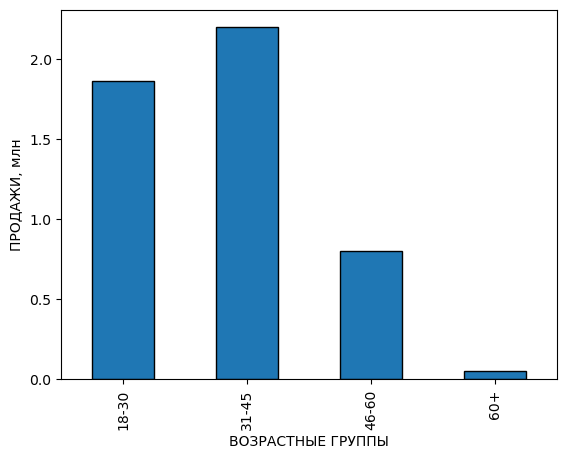

In [10]:
age_sales = df.groupby(pd.cut(df['Age'], bins=[17, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+']), observed=True)['Total_Amount'].sum()
age_sales_mlns = age_sales / 1000000
age_sales_mlns.plot(kind='bar', edgecolor='black')
plt.xlabel('ВОЗРАСТНЫЕ ГРУППЫ')
plt.ylabel('ПРОДАЖИ, млн')
plt.show()


Видим, что больше всего продано товаров в возрастной группе 31-45, что неудивительно, поскольку эта возрастная категория является самой экономически активной и платежеспособной.

---

Далее рассмотрим половозрастную структуру продаж.

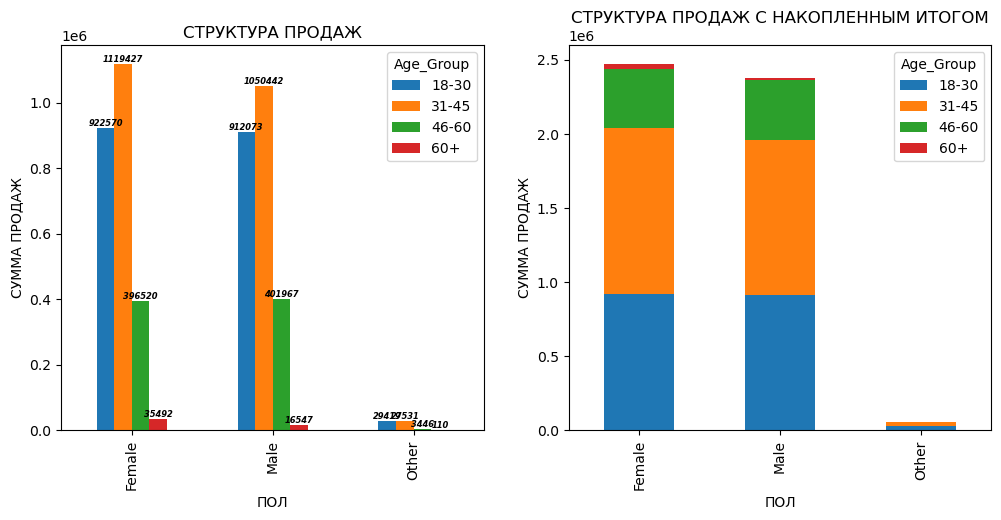

In [11]:
df['Age_Group'] = pd.cut(df['Age'], bins=[17, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])
age_gender_sales = df.groupby(['Gender', 'Age_Group'], observed=True)['Total_Amount'].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax1 = age_gender_sales.unstack().plot(kind='bar', ax=axes[0])
ax1.set_xlabel('ПОЛ')
ax1.set_ylabel('СУММА ПРОДАЖ')
ax1.set_title('CТРУКТУРА ПРОДАЖ')

for i in ax1.containers:
    ax1.bar_label(i, fmt='%.0f', fontsize=6, fontweight='bold', fontstyle='italic')


ax2 = age_gender_sales.unstack().plot(kind='bar', stacked=True, ax=axes[1])
ax2.set_xlabel('ПОЛ')
ax2.set_ylabel('СУММА ПРОДАЖ')
ax2.set_title('CТРУКТУРА ПРОДАЖ С НАКОПЛЕННЫМ ИТОГОМ')


plt.show()


Здесь в целом тоже ничего интересного - женщины из самой активной категории (31-45) покупают чуть больше, чем мужчины из этой же категории.

In [12]:
ltv = df.groupby('Customer_ID')['Total_Amount'].sum().round().mean()
display(Markdown(f'**Средняя пожизненная ценность клиента:** `{ltv}`'))

**Средняя пожизненная ценность клиента:** `983.1058`

---

Посмотрим на структуру продаж по категориям товаров:

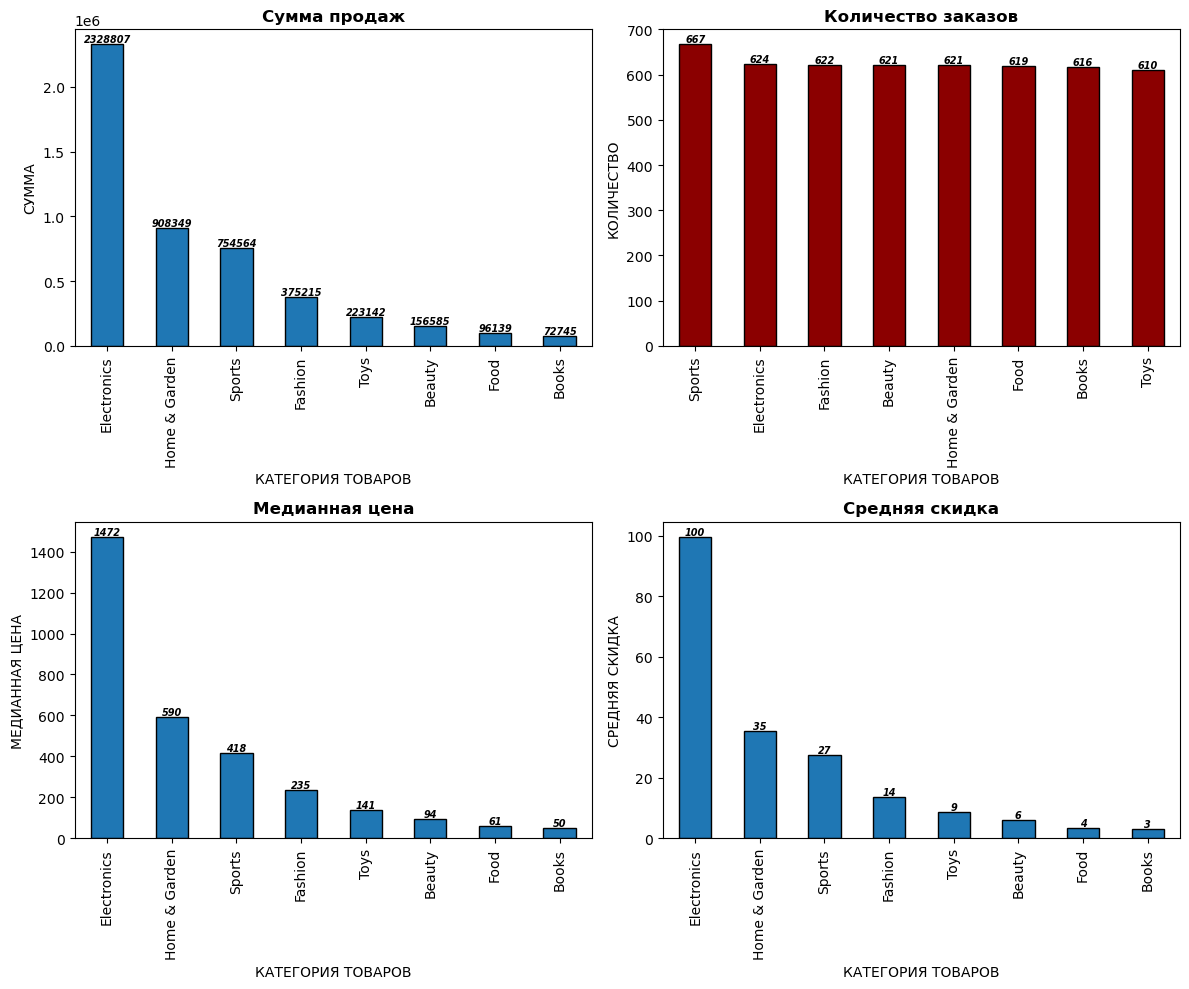

In [13]:
products_sales_sum = df.groupby('Product_Category')['Total_Amount'].sum().sort_values(ascending=False)
products_sales_count = df.groupby('Product_Category')['Total_Amount'].count().sort_values(ascending=False)
products_price_median = df.groupby('Product_Category')['Unit_Price'].median().sort_values(ascending=False)
products_discount_mean = df.groupby('Product_Category')['Discount_Amount'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(12,10))

ax1 = products_sales_sum.plot(kind='bar', ax=axes[0, 0], edgecolor='black', linewidth=1)
ax1.bar_label(ax1.containers[0], fmt='%.0f', fontsize=7, fontweight='bold', fontstyle='italic')
ax1.set_title('Сумма продаж', fontweight='bold')
ax1.set_xlabel('КАТЕГОРИЯ ТОВАРОВ')
ax1.set_ylabel('СУММА')

ax2 = products_sales_count.plot(kind='bar', ax=axes[0, 1], color='darkred', edgecolor='black', linewidth=1)
ax2.bar_label(ax2.containers[0], fmt='%.0f', fontsize=7, fontweight='bold', fontstyle='italic') 
ax2.set_title('Количество заказов', fontweight='bold')
ax2.set_xlabel('КАТЕГОРИЯ ТОВАРОВ')
ax2.set_ylabel('КОЛИЧЕСТВО')

ax3 = products_price_median.plot(kind='bar', ax=axes[1, 0], edgecolor='black', linewidth=1)
ax3.bar_label(ax3.containers[0], fmt='%.0f', fontsize=7, fontweight='bold', fontstyle='italic')
ax3.set_title('Медианная цена', fontweight='bold')
ax3.set_xlabel('КАТЕГОРИЯ ТОВАРОВ')
ax3.set_ylabel('МЕДИАННАЯ ЦЕНА')

ax4 = products_discount_mean.plot(kind='bar', ax=axes[1, 1], edgecolor='black', linewidth=1)
ax4.bar_label(ax4.containers[0], fmt='%.0f', fontsize=7, fontweight='bold', fontstyle='italic')
ax4.set_title('Средняя скидка', fontweight='bold')
ax4.set_xlabel('КАТЕГОРИЯ ТОВАРОВ')
ax4.set_ylabel('СРЕДНЯЯ СКИДКА')

plt.tight_layout()
plt.show()

In [14]:
category_stats = df.groupby('Product_Category').agg({
    'Total_Amount': ['sum', 'mean', 'count'],
    'Customer_Rating': 'mean',
    'Quantity': 'sum'
}).round(2)

category_stats.columns = ['Общая выручка', 'Средняя выручка', 'Количество заказов', 'Средний рейтинг', 'Число проданных товаров']
category_stats = category_stats.sort_values('Общая выручка', ascending=False)
display(Markdown('`Показатели продаж по категориям товаров`'))
display(category_stats)

`Показатели продаж по категориям товаров`

,Общая выручка,Средняя выручка,Количество заказов,Средний рейтинг,Число проданных товаров
Product_Category,,,,,
Electronics,2328806.81,3732.06,624,3.92,1379
Home & Garden,908348.86,1462.72,621,3.94,1353
Sports,754563.56,1131.28,667,3.90,1519
Fashion,375214.93,603.24,622,3.88,1411
Toys,223142.48,365.81,610,3.88,1368
Beauty,156584.74,252.15,621,3.91,1424
Food,96138.67,155.31,619,3.83,1355
Books,72744.52,118.09,616,3.97,1291


**Графики и таблица показывают весьма ровную картину:**
- во-первых, количество заказов по категориям практически одинаковое
- во-вторых, самая высокая медианная цена у товаров категории "Электроника", и эта же категория - ТОП-1 по продажам
- также в категории "Электроника" самая большая средняя скидка (100 лир). Следующая категоия по средней скидке - "Домашние и садовые товары" - всего 35 лир.

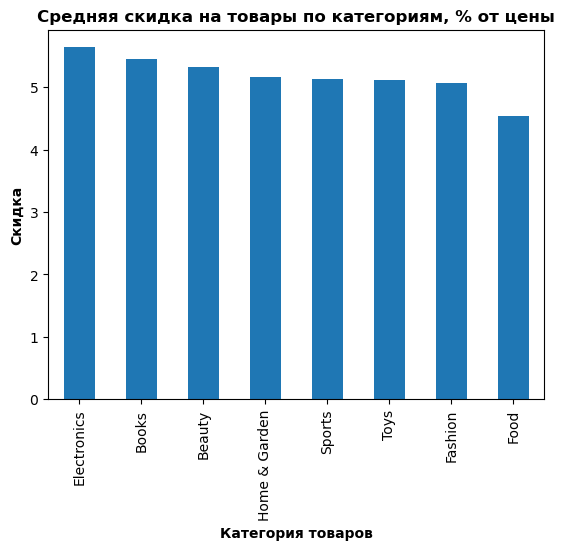

In [15]:
df['Discount_to_Price'] = (df['Discount_Amount'] / df['Unit_Price']) * 100

discount_to_price = df.groupby('Product_Category')['Discount_to_Price'].mean().sort_values(ascending=False)
discount_to_price.plot(kind='bar')
plt.title('Средняя скидка на товары по категориям, % от цены', fontweight='bold')
plt.xlabel('Категория товаров', fontweight='bold')
plt.ylabel('Скидка', fontweight='bold')
plt.show()

При этом в относительном выражении размер скидки +- одинаковый по всем категориям.

---

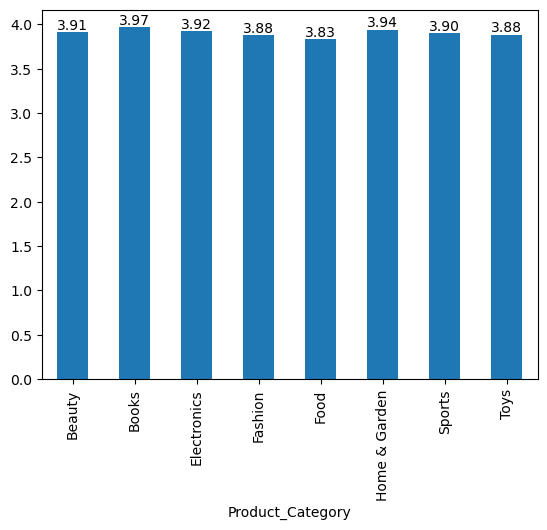

In [16]:
products_rating = df.groupby('Product_Category')['Customer_Rating'].mean()

labels = products_rating.plot(kind='bar')
labels.bar_label(labels.containers[0], fmt='%.2f')
plt.show()

Что касается рейтинга покупателей, то и он на одном уровне для всех категорий товаров! Разброс значений в диапазоне `**[3.83, 3.97]**`.

Таким образом, первоначальный анализ показывает *удивительно ровную картину по всем категориям товаров* - ровное количество продаж, одинаковые скидки и рейтинг по всем категориям.

**Далее проверим несколько гипотез в отношении влияния факторов, не связанных с ценой, на величину продаж.**
<br>

---

<br>

_**ГИПОТЕЗА 1. Чем больше время сессии, тем больше сумма покупки.**_

Чтобы проверить эту гипотезу, нужно найти коэффициент корреляции между временем сессии и суммой продаж:

**Коэффициент корреляции:** `-0.004`

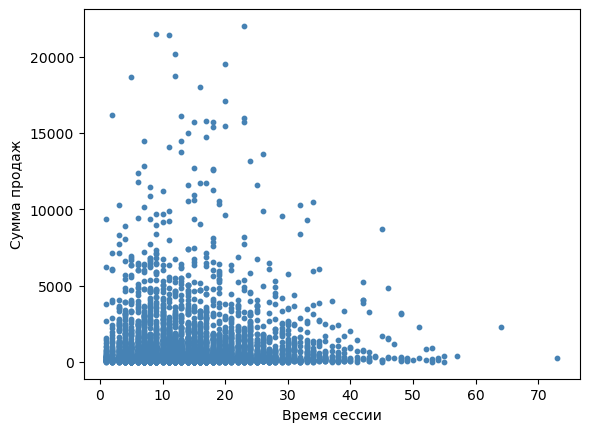

In [17]:
corr_coef = df[['Session_Duration_Minutes', 'Total_Amount']].corr().iloc[0, 1]
display(Markdown(f'**Коэффициент корреляции:** `{corr_coef:.3f}`'))

plt.scatter(df['Session_Duration_Minutes'], df['Total_Amount'], s=10, c='steelblue')
plt.xlabel('Время сессии')
plt.ylabel('Сумма продаж')
plt.show()

И коэффициент корреляции, и график показывают **отсутствие связи между временем сессии и суммой покупок**. `Гипотеза не подтвердилась`.

---
<br>

_**ГИПОТЕЗА 2.**_ Пользователи, которые на сайте **не в первый раз** (`Is_Returning_Customer == True`), тратят больше денег, чем новые пользователи.

<br>

In [18]:
returning_compare = df.groupby('Is_Returning_Customer')['Total_Amount'].median().reset_index()
display(returning_compare)

,Is_Returning_Customer,Total_Amount
0,False,326.71
1,True,348.71


In [19]:
group_old = df[df['Is_Returning_Customer'] == True]['Total_Amount']
group_new = df[df['Is_Returning_Customer'] == False]['Total_Amount']

u_stat, p_value = stats.mannwhitneyu(group_old, group_new, alternative='two-sided')

display(Markdown(f'**P-value: {p_value:.3f}** --> больше чем порог значимости 0.05'))


**P-value: 0.145** --> больше чем порог значимости 0.05

Как мы видим, разницы в тратах между "старыми" пользователями и "новыми" практически нет. 
**Также это видно U-тестом** (t-тест не используем из-за большого числа выбросов). `Гипотеза не подтвердилась`.

<br>

_**ГИПОТЕЗА 3.**_ Чем больше количество просмотренных страниц, тем больше сумма покупки.

<br>

**Коэффициент корреляции:** `-0.011831332180979417`

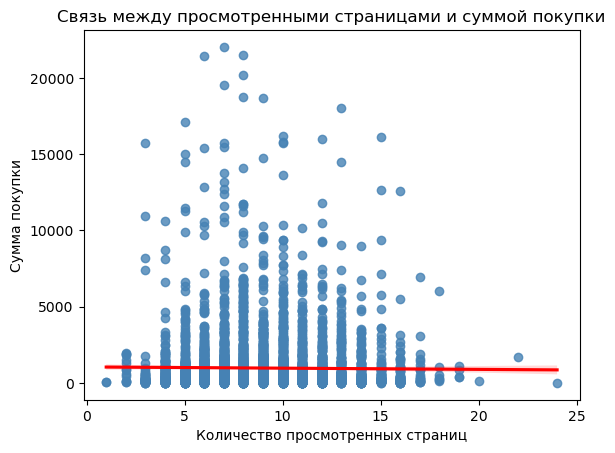

In [20]:
display(Markdown(f'**Коэффициент корреляции:** `{df[['Pages_Viewed', 'Total_Amount']].corr().iloc[1, 0]}`'))

sns.regplot(x='Pages_Viewed', y='Total_Amount', data=df, scatter_kws={'color': 'steelblue'}, line_kws={'color': 'red'}) 
# как plt.scatter, только с линией тренда

plt.title('Связь между просмотренными страницами и суммой покупки')
plt.xlabel('Количество просмотренных страниц')
plt.ylabel('Сумма покупки')
plt.show()


Связь не только очень слабая (практически отсутствует), но и отрицательная (и линия тренда горизонтальная). Это говорит о том, что просмотр страниц на сайте не влияет на итоговую сумму покупки. `Гипотеза не подтвердилась`.

<br>

_**ГИПОТЕЗА 4.**_ Наличие скидки на товар стимулирует к его покупке.

<br>

**Коэффициент корреляции:** `0.34757808899332104`

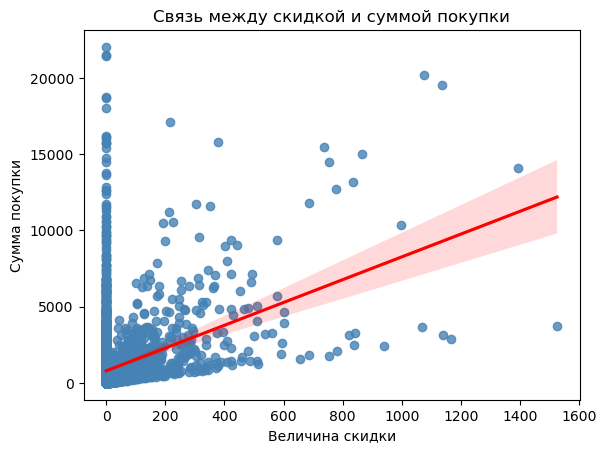

In [21]:
display(Markdown(f'**Коэффициент корреляции:** `{df[['Discount_Amount', 'Total_Amount']].corr().iloc[0, 1]}`'))

sns.regplot(x='Discount_Amount', y='Total_Amount', data=df, scatter_kws={'color': 'steelblue'}, line_kws={'color': 'red'}) 

plt.title('Связь между скидкой и суммой покупки')
plt.xlabel('Величина скидки')
plt.ylabel('Сумма покупки')
plt.show()

Видим, что, чем больше скидка, тем выше сумма покупки, но эта зависимость не сильная — на общую сумму влияют и другие факторы. `Гипотеза частично подтвердилась`.

<br>

_**ГИПОТЕЗА 5.**_ Тип устройства влияет на сумму покупки.

<br>

In [22]:
display(df.groupby('Device_Type')['Total_Amount'].median().reset_index().round(0))

,Device_Type,Total_Amount
0,Desktop,337.0
1,Mobile,349.0
2,Tablet,281.0


Видим, что больше всего покупок совершаются со смартфона и компьютера, **а меньше всего  - с планшета**. `Гипотеза подтвердилась - тип устройства влияет на итоговую сумму покупки`.

<br>

_**ГИПОТЕЗА 6.**_ Время доставки влияет на пользовательскую оценку сайта(магазина).

<br>

In [23]:
display(Markdown(f'**Коэффициент корреляции:** `{df[['Delivery_Time_Days', 'Customer_Rating']].corr().iloc[0, 1]}`'))

**Коэффициент корреляции:** `-0.00994777493859946`

Удивительно, но оценка магазина совершенно не зависит от времени доставки - даже при длительном ожидании оценка может быть высокой, и низкой - при быстром ожидании. `Гипотеза не подтвердилась`.

---

### Выводы

Важно оговориться, что результаты анализа показали недостаток использования синтетических данных, коими является данный датасет. Многие показатели в динамике ведут себя не так, как это обычно бывает на "живых" данных. В частности:

- **отсутствует сезонность**, месячные продажи одинаковые за рассматриваемый период;
- **половая структура продаж:** разница между мужчинами и женщинами по сумме покупок фактически отсутствует.
- **возрастная структура продаж:** присутствует сильный выброс в значениях на возрасте `18  лет`. **Возможно, что при заполнении возраста, все несовершеннолетние пользователи отмечали именно "18"**. В пользу этого говорит отсутствие null-значений по этому столбцу - все пользователи так или иначе заполнили графу возраста, даже если там не было подходящего варианта.

Что касается выявленных зависимостей:
было сформулировано **6 гипотез** относительно влияния разных факторов на величину продаж. По сути, подтвердились только **2 гипотезы**:

- скидка влияет на сумму покупки, однако связь достаточно _слабая_, т.е это не основной фактор принятия решения о покупке со стороны клиента.
- тип устройства влияет на сумму покупки: в среднем _самое "продающее" устройство - смартфон_, на втором месте - компьютер, а самое "непродающее" - планшет.

**Важное наблюдение:** `время на сайте и количество просмотренных страниц никак не влияют на принятие решение о покупке. Это значит, что сам сайт не вовлекает и не стимулирует на "побочные" покупки.`

**Рекомендации:**

- максимально упростить и сократить "серфинг" пользователей в процессе покупки - добавить блоки *"Похожие товары"*, *"С этим покупают"* и т.п. (как на маркетплейсах), чтобы сподвигнуть покупать не только целевой товар.
- с точки зрения *ux\ui*-дизайна произвести изменения в mobile- и desktop- версиях сайта. Поработать с интерфейсом, оценить конверсию и провести A/B-тесты.
